In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def polinomios_legendre(n_max, x):

    # Crearemos primero un array donde se guerden los polinomios de Legendre. 
    P = np.zeros((n_max + 1, len(x))) 

    # Condicion para el primer polinomio de Legendre
    P[0, :] = 1

    if n_max > 0: 
        P[1, :] = x

    for n in range(2, n_max + 1):
        P[n+1, :] = ((2 * n + 1)*x * P[n, :] - n * P[n-1, :])/(n+1)
    
    return P 



In [2]:
import numpy as np

def build_legendre_matrix(N):
    """
    Builds the transformation matrix C of size (N+1, N+1).
    C[k, n] is the coefficient of x^k in the polynomial P_n(x).
    """
    C = np.zeros((N + 1, N + 1))
    
    # Base cases: P_0(x) = 1, P_1(x) = x
    C[0, 0] = 1.0
    if N >= 1:
        C[1, 1] = 1.0
        
    # Build higher orders using the recurrence relation:
    # (n+1)P_{n+1} = (2n+1)xP_n - nP_{n-1}
    # P_{n+1} = [(2n+1)/(n+1)] * x * P_n - [n/(n+1)] * P_{n-1}
    for n in range(1, N):
        # To multiply P_n by x computationally, we shift all coefficients up by one index
        x_Pn = np.roll(C[:, n], 1)
        x_Pn[0] = 0.0  # The constant term becomes 0 when multiplied by x
        
        # Apply the recurrence formula algebraically
        C[:, n+1] = ((2*n + 1) / (n + 1)) * x_Pn - (n / (n + 1)) * C[:, n-1]
        
    return C

def solve_legendre_coefficients(a_coeffs):
    """
    Transforms monomial coefficients a_n to Legendre coefficients b_n.
    a_coeffs: array [a_0, a_1, a_2, ..., a_N] where a_n is the coefficient of x^n
    """
    N = len(a_coeffs) - 1
    
    # 1. Build the matrix that maps b -> a
    C = build_legendre_matrix(N)
    
    # 2. Solve the linear system C * b = a  for b
    # (We use np.linalg.solve instead of np.linalg.inv for better numerical stability)
    b_coeffs = np.linalg.solve(C, a_coeffs)
    
    return b_coeffs

# --- Example Application ---
# Let's say your polynomial is y(x) = 2 - 3x + 4x^2
# In monomial basis, a = [2, -3, 4]
a = np.array([2.0, 1.0, -2.0, 3.0, -3.0, -2.0, -1.7])

b = solve_legendre_coefficients(a)

print("Monomial coefficients (a_n):", a)
print("Legendre coefficients (b_n):", np.round(b, 4))

Monomial coefficients (a_n): [ 2.   1.  -2.   3.  -3.  -2.  -1.7]
Legendre coefficients (b_n): [ 0.4905  1.9429 -3.8571  0.3111 -1.2156 -0.254  -0.1177]


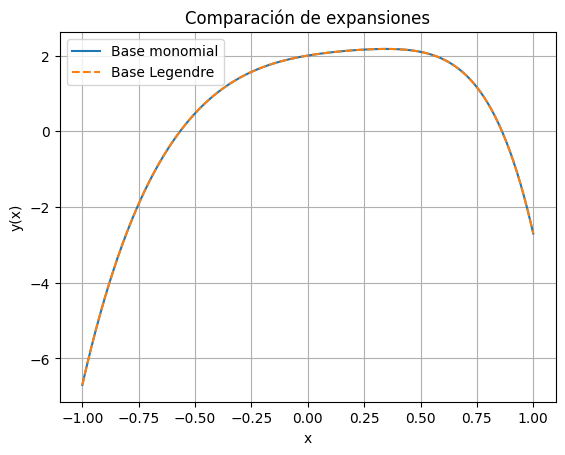

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def eval_monomial(x, a):
    """Evalúa el polinomio en base monomial"""
    y = np.zeros_like(x)
    for n in range(len(a)):
        y += a[n] * x**n
    return y

def eval_legendre(x, b):
    """Evalúa la expansión en polinomios de Legendre"""
    N = len(b) - 1
    
    # Inicialización
    P = np.zeros((N+1, len(x)))
    P[0] = 1
    if N >= 1:
        P[1] = x
    
    # Recurrencia de Legendre
    for n in range(1, N):
        P[n+1] = ((2*n + 1)/(n + 1)) * x * P[n] - (n/(n + 1)) * P[n-1]
    
    # Construir y(x)
    y = np.zeros_like(x)
    for n in range(N+1):
        y += b[n] * P[n]
    
    return y

# Dominio
x = np.linspace(-1, 1, 500)

# Evaluaciones
y_mono = eval_monomial(x, a)
y_leg = eval_legendre(x, b)

# Gráfica
plt.figure()
plt.plot(x, y_mono, label="Base monomial")
plt.plot(x, y_leg, '--', label="Base Legendre")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Comparación de expansiones")
plt.legend()
plt.grid()
plt.show()